In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from scipy.fft import fft, fftfreq

In [42]:
class GravitationalWave:
  def __init__(self):
    self.h0 = 1
    self.tau = 2 #s
    self.f0 = 30 #Hz
    self.f2 = 20 #Hz^3
    self.n0 = 10
    self.fs = 16384 #Hz
    self.dt = 1/self.fs


  def windowed(self):
    # Durata 5 secondi
    t = np.arange(0, 5, self.dt)

    # Generazione h(t)
    A_t = self.h0 * 1e-21 * np.exp(t / self.tau)
    phi_t = 2 * np.pi * (self.f0 * t + self.f2 * (t**3) / 3)
    h_t_iniziale = A_t * np.sin(phi_t)

    self.h_t = h_t_iniziale * tukey(len(h_t_iniziale), alpha = 0.1)

    # Creo l'array di zeri (25 secondi)
    zeri_25s = np.zeros(int(25 / self.dt))

    # Concateno: zeri + segnale (5s) + zeri = 55s totali
    self.s_t = np.concatenate([zeri_25s, self.h_t, zeri_25s])

    # Vettore dei tempi per s(t)
    self.t_s = np.arange(0,len(self.s_t)) * self.dt


  def strain(self):
    # d(t) = s(t) + rumore (55s totali)
    #rumore gaussiao con media 0 e deviaizone stadard = self.n0 * 1e-21
    noise = np.random.normal(0, self.n0 * 1e-21, len(self.s_t))

    self.d_t = (self.s_t + noise) * tukey(len(self.s_t), alpha= 0.1)

  def filter(self):
    # Convoluzione rho(t) con t_rho = 60s (full somma gli array)
    self.rho_t = np.convolve(self.d_t, self.h_t, mode='full')
    self.t_rho = np.arange(0, len(self.rho_t)) * self.dt

  def fft(self):
    # trasformata di Fourier
    s_fft = fft(self.s_t)
    s_quadro = np.abs(s_fft)**2
    frequenza = fftfreq(len(self.s_t), self.dt)

    # impongo le limitazioni per il grafico di |s(f)|^2
    indices = np.where((frequenza >= self.f0) & (frequenza <= self.fs / 2))
    self.f_plot = frequenza[indices]
    self.squadro_plot = s_quadro[indices]

  def visualizza(self):
    fig, ax = plt.subplots(3, 1, figsize=(10, 12))

    # Plot 1: Segnale e Rumore
    ax[0].plot(self.t_s, self.d_t, color='silver', label='d(t) (Strain)')
    ax[0].plot(self.t_s, self.s_t, color='blue', label='s(t) (Windowed)')
    ax[0].legend()

    # Plot 2: Filtro (convoluzione)
    ax[1].plot(self.t_rho, self.rho_t, color='green')
    #cerco il massimo
    Max = np.argmax(self.rho_t)
    ax[1].plot(self.t_rho[Max], self.rho_t[Max], 'ro') # Max
    ax[1].set_title("Filtro (Convoluzione)- rho")

    # Plot 3: |s(f)|^2 in scala logaritmica
    ax[2].loglog(self.f_plot, self.squadro_plot, color='purple')
    #cerco il massimo
    Massimo = np.argmax(self.squadro_plot)
    ax[2].plot(self.f_plot[Massimo], self.squadro_plot[Massimo], 'ro') # Max
    ax[2].set_title("|s(f)|^2")

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


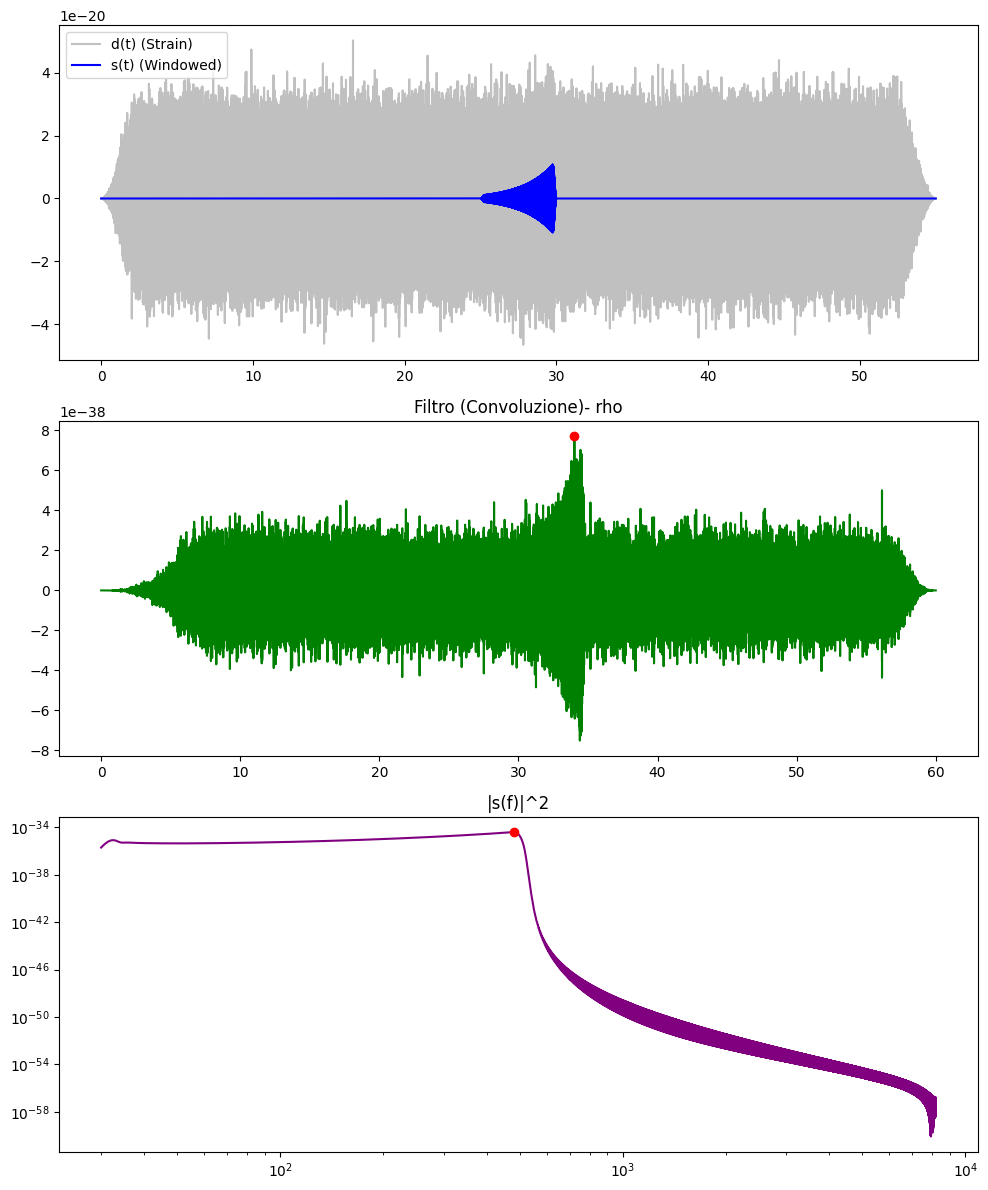

In [41]:
onda = GravitationalWave()
onda.windowed()
onda.strain()
onda.filter()
onda.fft()
onda.visualizza()